In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

# Set your image folder path here
IMAGE_DIR = "./Agricultural_Image_Analytics\\leaves"  # change this to wherever your I1.png ... I8.png are

IMAGE_FILES = sorted([f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')])
print("Found:", IMAGE_FILES)

Found: ['I1.png', 'I2.png', 'I3.png', 'I4.png', 'I5.png', 'I6.png', 'I7.png', 'I8.png']


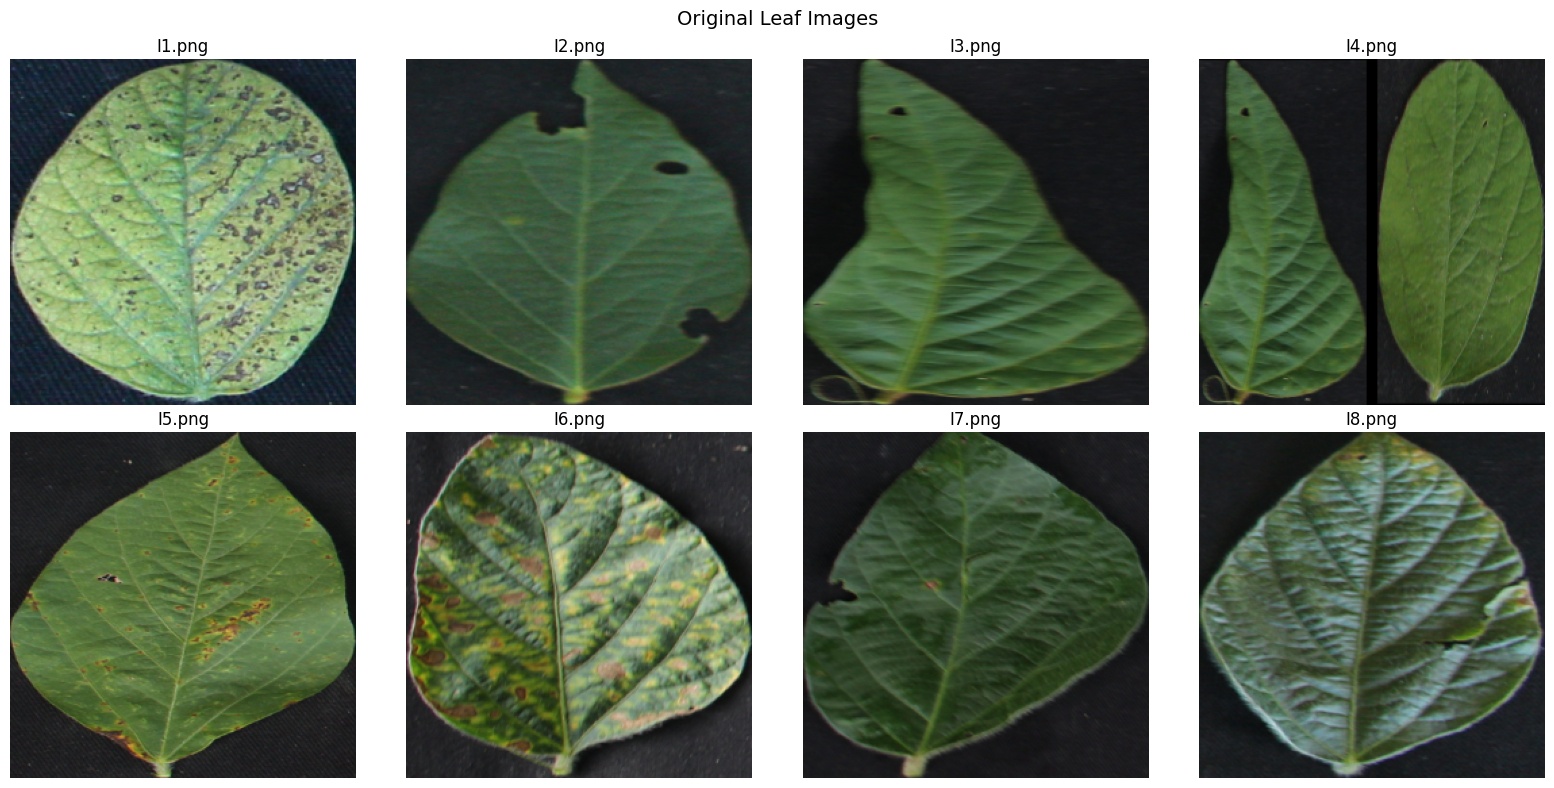

In [2]:
#loading images

def load_image(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

images = {fn: load_image(os.path.join(IMAGE_DIR, fn)) for fn in IMAGE_FILES}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (fn, img) in zip(axes.flat, images.items()):
    ax.imshow(img)
    ax.set_title(fn)
    ax.axis('off')
plt.suptitle("Original Leaf Images", fontsize=14)
plt.tight_layout()
plt.show()

Task 1: Data Augmentation

In [3]:
def elastic_warp(image, alpha=30, sigma=5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    h, w = image.shape[:2]
    dx = gaussian_filter((rng.random((h, w)) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((rng.random((h, w)) * 2 - 1), sigma) * alpha
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    map_x = np.clip(x + dx, 0, w - 1).astype(np.float32)
    map_y = np.clip(y + dy, 0, h - 1).astype(np.float32)
    return cv2.remap(image, map_x, map_y,
                     interpolation=cv2.INTER_LINEAR,
                     borderMode=cv2.BORDER_REFLECT)

def augment_image(image, rng):
    h, w = image.shape[:2]
    angle = rng.uniform(-45, 45)       # random rotate
    scale = rng.uniform(0.8, 1.2)      # random scale
    tx    = rng.uniform(-0.15, 0.15) * w  # random shift x
    ty    = rng.uniform(-0.15, 0.15) * h  # random shift y

    M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    M[0, 2] += tx
    M[1, 2] += ty
    transformed = cv2.warpAffine(image, M, (w, h),
                                  flags=cv2.INTER_LINEAR,
                                  borderMode=cv2.BORDER_REFLECT)
    warped = elastic_warp(transformed,
                          alpha=rng.uniform(10, 40),
                          sigma=rng.uniform(3, 7), rng=rng)
    return warped

print("Augmentation functions defined.")

Augmentation functions defined.


Generated 100 augmented images.


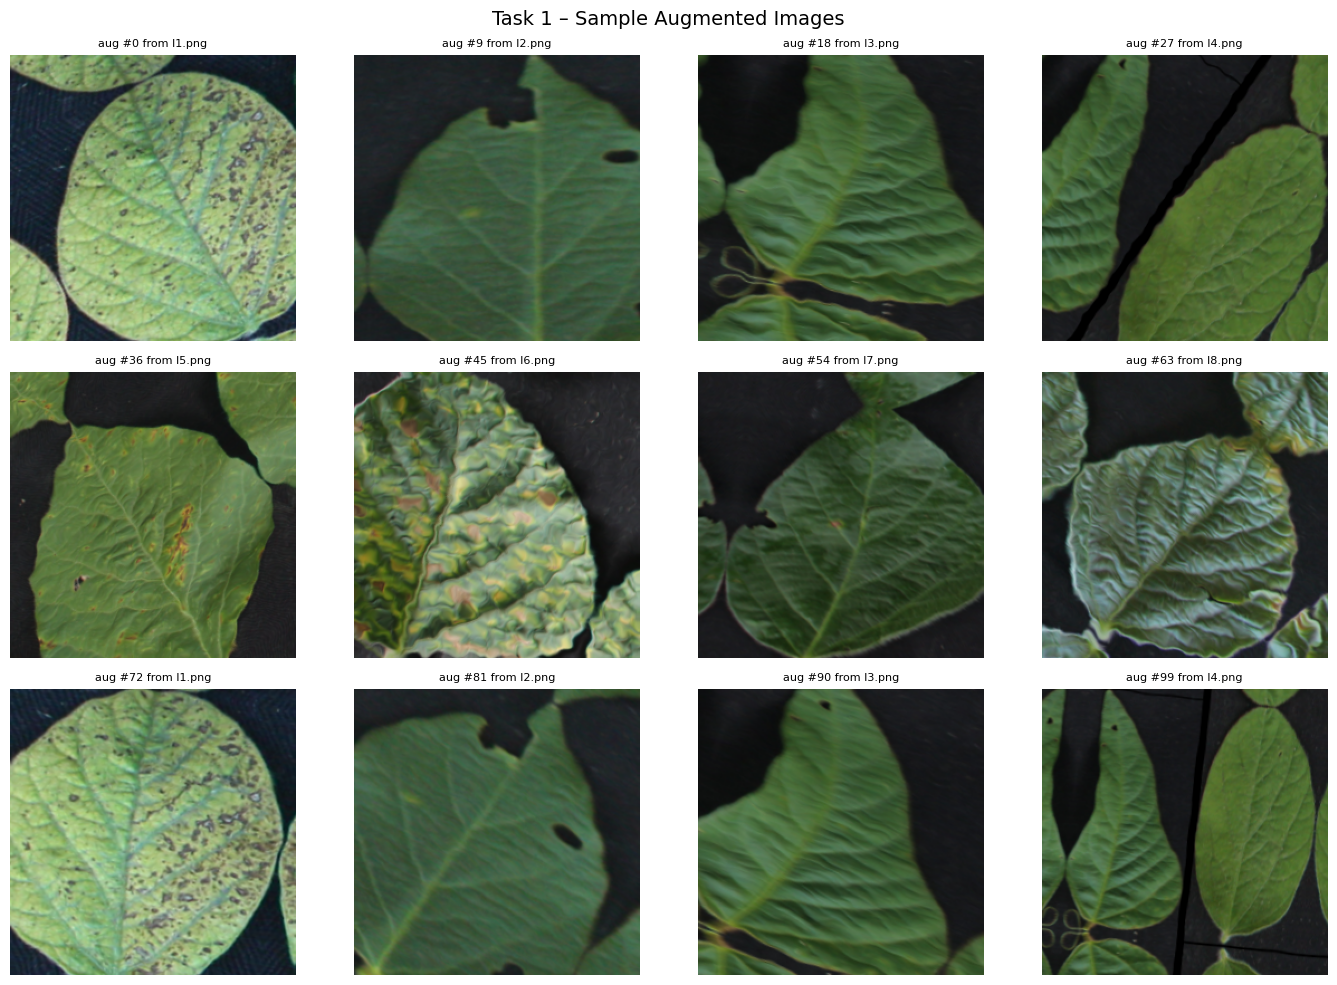

In [4]:
rng = np.random.default_rng(42)
augmented = []

for i in range(100):
    src_name = IMAGE_FILES[i % len(IMAGE_FILES)]
    aug = augment_image(images[src_name], rng)
    augmented.append((src_name, aug))

print(f"Generated {len(augmented)} augmented images.")

# Show 12 samples
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle("Task 1 – Sample Augmented Images", fontsize=14)
for ax, idx in zip(axes.flat, np.linspace(0, 99, 12, dtype=int)):
    ax.imshow(augmented[idx][1])
    ax.set_title(f"aug #{idx} from {augmented[idx][0]}", fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

Task 2: Extract local patches

Patches shape: (1600, 32, 32, 3)


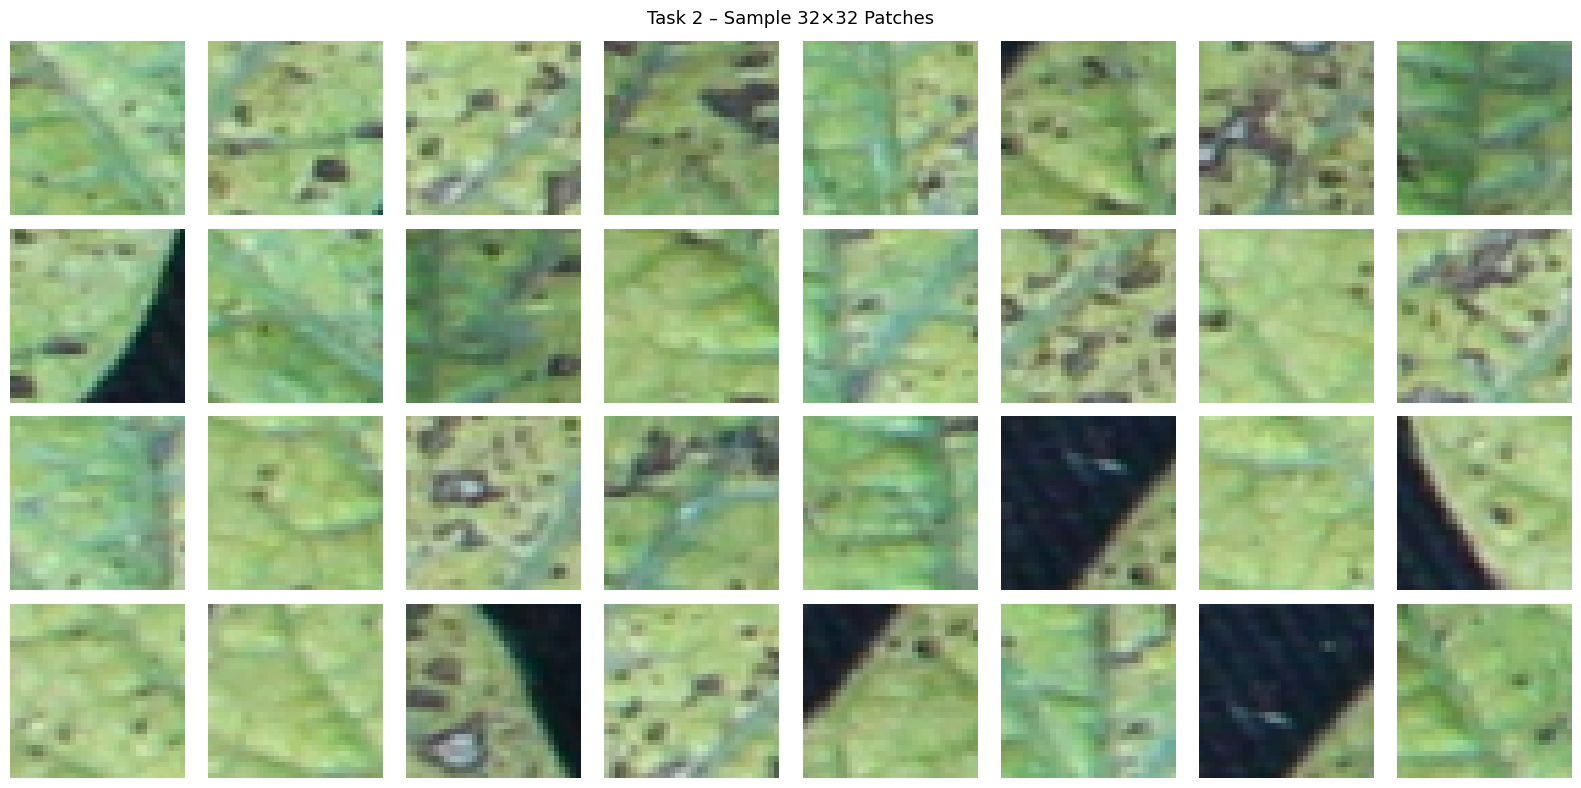

In [5]:
PATCH_SIZE = 32
N_PATCHES  = 200   # per image

all_patches = []

for fn, img in images.items():
    h, w = img.shape[:2]
    for _ in range(N_PATCHES):
        r = rng.integers(0, h - PATCH_SIZE)
        c = rng.integers(0, w - PATCH_SIZE)
        patch = img[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        all_patches.append(patch)

all_patches = np.array(all_patches, dtype=np.float32)
print(f"Patches shape: {all_patches.shape}")  # (1600, 32, 32, 3)

# Show first 32
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("Task 2 – Sample 32×32 Patches", fontsize=13)
for ax, p in zip(axes.flat, all_patches[:32]):
    ax.imshow(p.astype(np.uint8))
    ax.axis('off')
plt.tight_layout()
plt.show()

Task 3: ZCA Whitening

ZCA whitened shape: (1600, 3072)


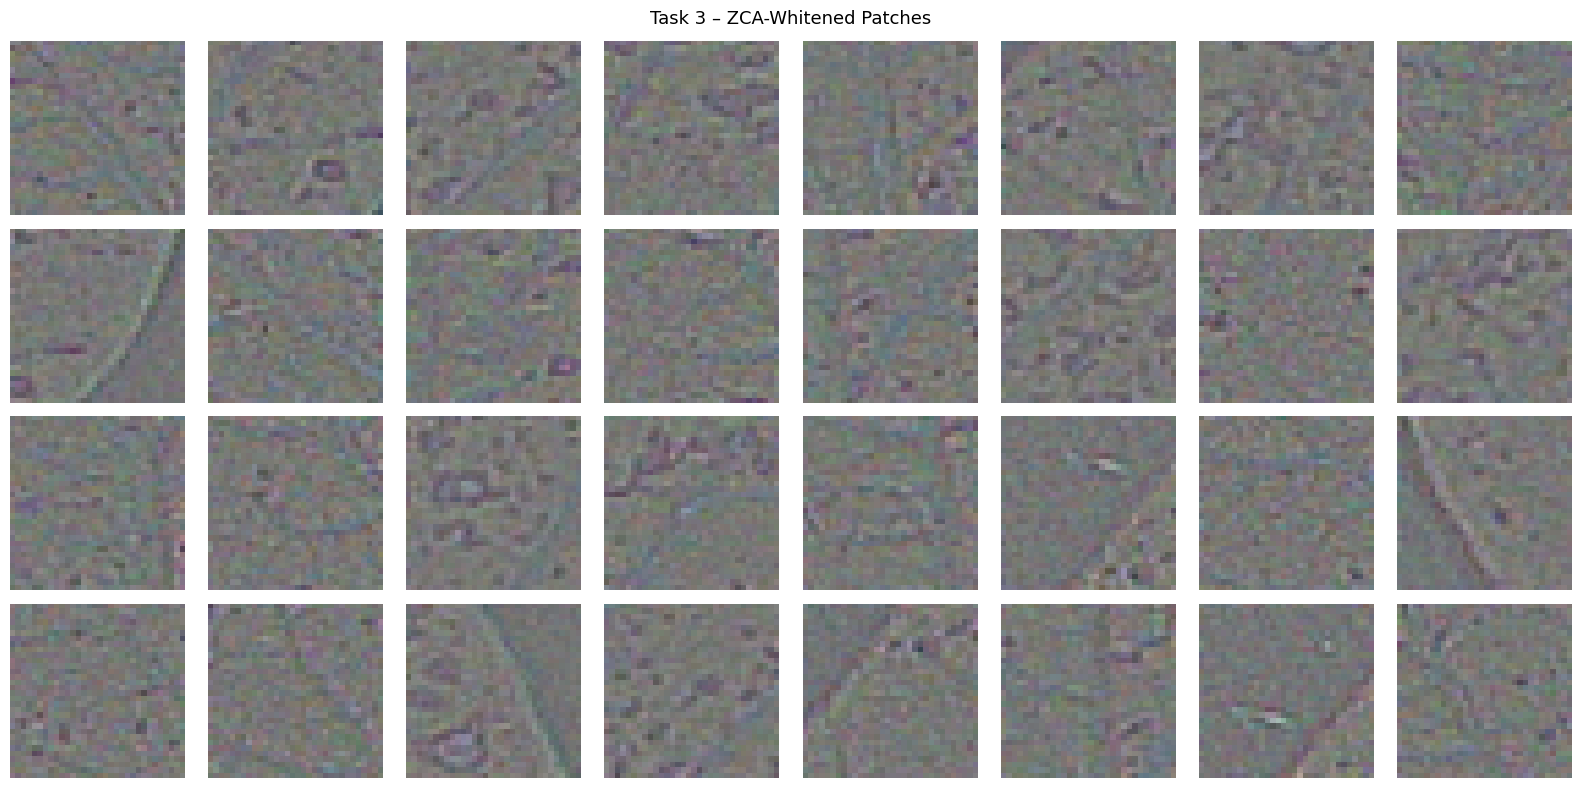

In [6]:
N = len(all_patches)
d = PATCH_SIZE * PATCH_SIZE * 3

# Flatten & normalize
X = all_patches.reshape(N, d) / 255.0

# Mean-center
mu = X.mean(axis=0)
X_c = X - mu

# Covariance
cov = (X_c.T @ X_c) / N

# SVD
U, S, Vt = np.linalg.svd(cov, full_matrices=False)

# ZCA transform matrix
eps = 1e-5
W_zca = (U * (1.0 / np.sqrt(S + eps))) @ U.T

# Apply ZCA
X_white = X_c @ W_zca.T
print(f"ZCA whitened shape: {X_white.shape}")

# Rescale to [0,1] for display
X_vis = X_white - X_white.min()
X_vis = X_vis / (X_vis.max() + 1e-8)
patches_white_vis = X_vis.reshape(N, PATCH_SIZE, PATCH_SIZE, 3)

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("Task 3 – ZCA-Whitened Patches", fontsize=13)
for ax, p in zip(axes.flat, patches_white_vis[:32]):
    ax.imshow(np.clip(p, 0, 1))
    ax.axis('off')
plt.tight_layout()
plt.show()

 Task 4 & 5: Channel distributions (side by side)

Red  | Original → μ=0.2827, σ=0.1580  | Whitened → μ=-0.0000, σ=0.6779
Green  | Original → μ=0.3598, σ=0.1864  | Whitened → μ=0.0000, σ=0.6663
Blue  | Original → μ=0.2415, σ=0.1347  | Whitened → μ=0.0000, σ=0.6622


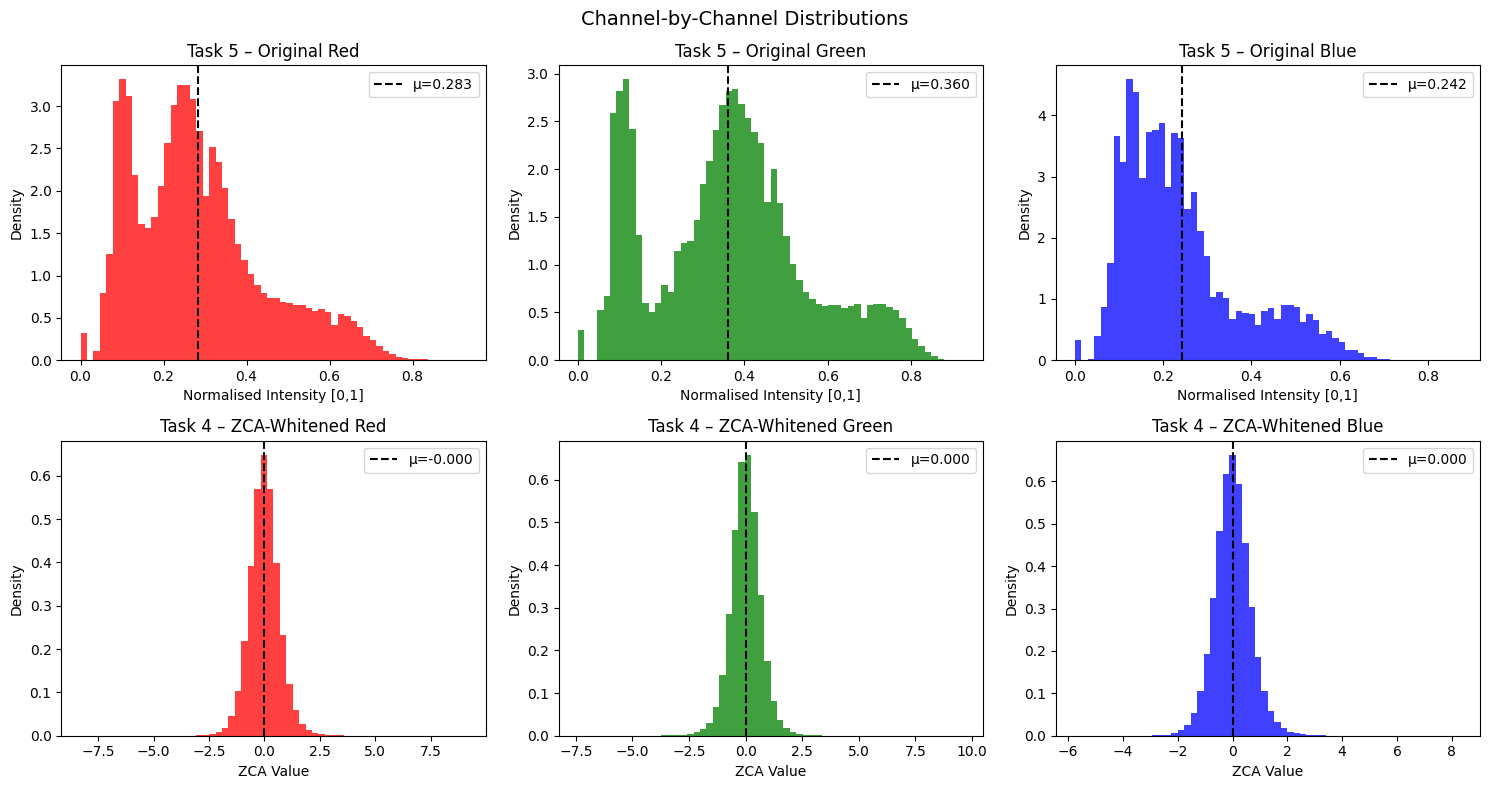

In [7]:
channel_names = ['Red', 'Green', 'Blue']
colors        = ['red', 'green', 'blue']

orig_flat  = all_patches.reshape(N, PATCH_SIZE, PATCH_SIZE, 3) / 255.0
white_flat = X_white.reshape(N, PATCH_SIZE, PATCH_SIZE, 3)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Channel-by-Channel Distributions", fontsize=14)

for ch, (name, col) in enumerate(zip(channel_names, colors)):
    # Original (Task 5)
    data_orig = orig_flat[:, :, :, ch].ravel()
    axes[0, ch].hist(data_orig, bins=60, color=col, alpha=0.75, density=True)
    axes[0, ch].axvline(data_orig.mean(), color='black', linestyle='--',
                         label=f"μ={data_orig.mean():.3f}")
    axes[0, ch].set_title(f"Task 5 – Original {name}")
    axes[0, ch].set_xlabel("Normalised Intensity [0,1]")
    axes[0, ch].set_ylabel("Density")
    axes[0, ch].legend()

    # Whitened (Task 4)
    data_w = white_flat[:, :, :, ch].ravel()
    axes[1, ch].hist(data_w, bins=60, color=col, alpha=0.75, density=True)
    axes[1, ch].axvline(data_w.mean(), color='black', linestyle='--',
                         label=f"μ={data_w.mean():.3f}")
    axes[1, ch].set_title(f"Task 4 – ZCA-Whitened {name}")
    axes[1, ch].set_xlabel("ZCA Value")
    axes[1, ch].set_ylabel("Density")
    axes[1, ch].legend()

    print(f"{name}  | Original → μ={data_orig.mean():.4f}, σ={data_orig.std():.4f}"
          f"  | Whitened → μ={data_w.mean():.4f}, σ={data_w.std():.4f}")

plt.tight_layout()
plt.show()